# ESG Multi-Agent Orchestration — Hyperparameter Analysis

**Question:** is an agent-based pipeline suitable for ESG report scoring, and which
hyperparameter configuration of the orchestration is the better bet?

**Experimental design.** One orchestration system, five configurations (one file each):

| label | file | what is varied |
|---|---|---|
| `control` | uploaded baseline | default settings |
| `high_handoff` | `..._high_handoff_...` | handoff weight turned up |
| `high_parallel` | `..._high_parallel_...` | parallel weight turned up |
| `high_review` | `..._high_review_...` | review weight turned up |
| `no_critique` | `..._no_critique_...` | critique step disabled |

Each file internally reports three sub-patterns
(`parallel_concurrent`, `handoff_hierarchical`, `review_critique`).
The **comparison axis is the configuration (the file)**; `FOCUS_PATTERN` below lets you
either pool the sub-patterns or zoom into one.

In [1]:
import os, json
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## 1 · Configuration

Source files live in `./output/`, this notebook in `./output/results/`, so `DATA_DIR = '..'`.
A notebook has no `__file__`; paths resolve from the notebook's own folder, so `'..'` is
reliable here. Set an absolute path if you ever move the notebook.

In [2]:
# --- where the source JSON files live (relative to this notebook) ---
DATA_DIR = '..'

# --- the five configurations: label -> filename ---
FILES = OrderedDict([
    ('control',       'esg_experiment_sustainalytics_control_20260602_173153.json'),
    ('high_handoff',  'esg_experiment_sustainalytics_high_handoff_20260602_224824.json'),
    ('high_parallel', 'esg_experiment_sustainalytics_high_parallel_20260602_205554.json'),
    ('high_review',   'esg_experiment_sustainalytics_high_review_20260603_003012.json'),
    ('no_critique',   'esg_experiment_sustainalytics_no_critique_20260602_191347.json'),
])
EXPERIMENTS = OrderedDict((lbl, os.path.join(DATA_DIR, fn)) for lbl, fn in FILES.items())

# --- which internal sub-pattern to analyse ---
#   'all'  -> pool the three sub-patterns (overall behaviour of each config)
#   or one of: 'parallel_concurrent' | 'handoff_hierarchical' | 'review_critique'
FOCUS_PATTERN = 'all'

# --- save figures to disk as well as showing them inline? ---
SAVE_FIGS = False
FIG_DIR   = 'figures'

# --- composite-suitability weighting (business priorities, auto-normalised) ---
SUITABILITY_WEIGHTS = {
    'validity': 0.35, 'trust': 0.25, 'coverage': 0.15, 'cost': 0.15, 'judge_agreement': 0.10,
}

REPORT_METRIC_KEYS = [
    'mae_total', 'accuracy', 'bias_total', 'judge_accuracy',
    'hallucination_unsupported', 'hallucination_partial',
    'consistency_quantitative', 'latency_total', 'latency_critical_path',
    'token_efficiency', 'coverage_weighted', 'coverage_partial',
    'coverage_per_call', 'agreement_pairwise_pearson', 'agreement_fleiss_kappa',
    'conflict_detection_rate', 'resolution_quality', 'deliberation_quality',
    'dominance_ratio',
]

## 2 · Load & parse

In [3]:
def _load_one(src):
    if isinstance(src, dict):
        return src
    with open(src, 'r', encoding='utf-8') as fh:
        return json.load(fh)

def _safe(d, k, default=np.nan):
    v = d.get(k, default)
    return v if v is not None else default

def load_experiments(experiments):
    """Return tidy reports_df / domains_df / summary_df. Missing files skipped."""
    rep, dom, summ = [], [], []
    for lbl, src in experiments.items():
        try:
            data = _load_one(src)
        except (FileNotFoundError, json.JSONDecodeError, TypeError) as e:
            print(f'  [skip] {lbl}: {e}')
            continue
        patterns = data.get('patterns') or list((data.get('results') or {}).keys())
        for pat, smap in (data.get('summary') or {}).items():
            summ.append({'experiment': lbl, 'pattern': pat, **smap})
        for pat in patterns:
            for rec in (data.get('results') or {}).get(pat, []):
                comp = rec.get('comparison', {}) or {}
                metr = rec.get('metrics', {}) or {}
                meta = rec.get('metadata', {}) or {}
                row = {
                    'experiment': lbl, 'pattern': pat, 'report_id': rec.get('report_id'),
                    'total_score': _safe(rec, 'total_score'), 'confidence': _safe(rec, 'confidence'),
                    'actual_total': _safe(comp, 'actual_total'),
                    'absolute_error': _safe(comp, 'absolute_error'),
                    'percentage_error': _safe(comp, 'percentage_error'),
                    'direction': comp.get('direction'),
                    'conflicts': meta.get('conflicts'), 'resolved': meta.get('resolved'),
                }
                for mk in REPORT_METRIC_KEYS:
                    row[mk] = _safe(metr, mk)
                rep.append(row)
                for dname, dv in (rec.get('domain_scores') or {}).items():
                    dom.append({'experiment': lbl, 'pattern': pat, 'report_id': rec.get('report_id'),
                                'domain': dname, 'estimated_score': _safe(dv, 'estimated_score'),
                                'confidence': _safe(dv, 'confidence'), 'label': dv.get('label')})
    return pd.DataFrame(rep), pd.DataFrame(dom), pd.DataFrame(summ)

In [4]:
reports_raw, domains_raw, summary_df = load_experiments(EXPERIMENTS)

# apply the focus filter and set the comparison key = configuration
def apply_focus(df):
    df = df.copy()
    if FOCUS_PATTERN != 'all':
        df = df[df['pattern'] == FOCUS_PATTERN]
    df['group'] = df['experiment']
    # keep configurations in the intended order
    order = [l for l in FILES if l in set(df['group'])]
    df['group'] = pd.Categorical(df['group'], categories=order, ordered=True)
    return df

reports_df = apply_focus(reports_raw)
domains_df = apply_focus(domains_raw)

print(f'FOCUS_PATTERN = {FOCUS_PATTERN!r}')
print(f'{len(reports_df)} report rows across configs: {list(reports_df["group"].cat.categories)}')
reports_df.groupby('group', observed=True)['report_id'].count().rename('rows')

FOCUS_PATTERN = 'all'
450 report rows across configs: ['control', 'high_handoff', 'high_parallel', 'high_review', 'no_critique']


group
control          90
high_handoff     90
high_parallel    90
high_review      90
no_critique      90
Name: rows, dtype: int64

## 3 · Plot helpers

In [5]:
GROUPS = lambda df: list(df['group'].cat.categories)

def palette(n):
    return plt.cm.tab10(np.linspace(0, 1, max(n, 3)))[:n]

def minmax(series, higher_is_better=True):
    s = pd.to_numeric(series, errors='coerce')
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        return pd.Series(0.5, index=series.index)
    out = (s - lo) / (hi - lo)
    return out if higher_is_better else 1 - out

def finish(fig, name):
    fig.tight_layout()
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')
    plt.show()

## 4 · Scoring validity

How close are the agent scores to the real Sustainalytics totals? Accuracy, mean
absolute error (with spread), signed bias, and the per-report error distribution.

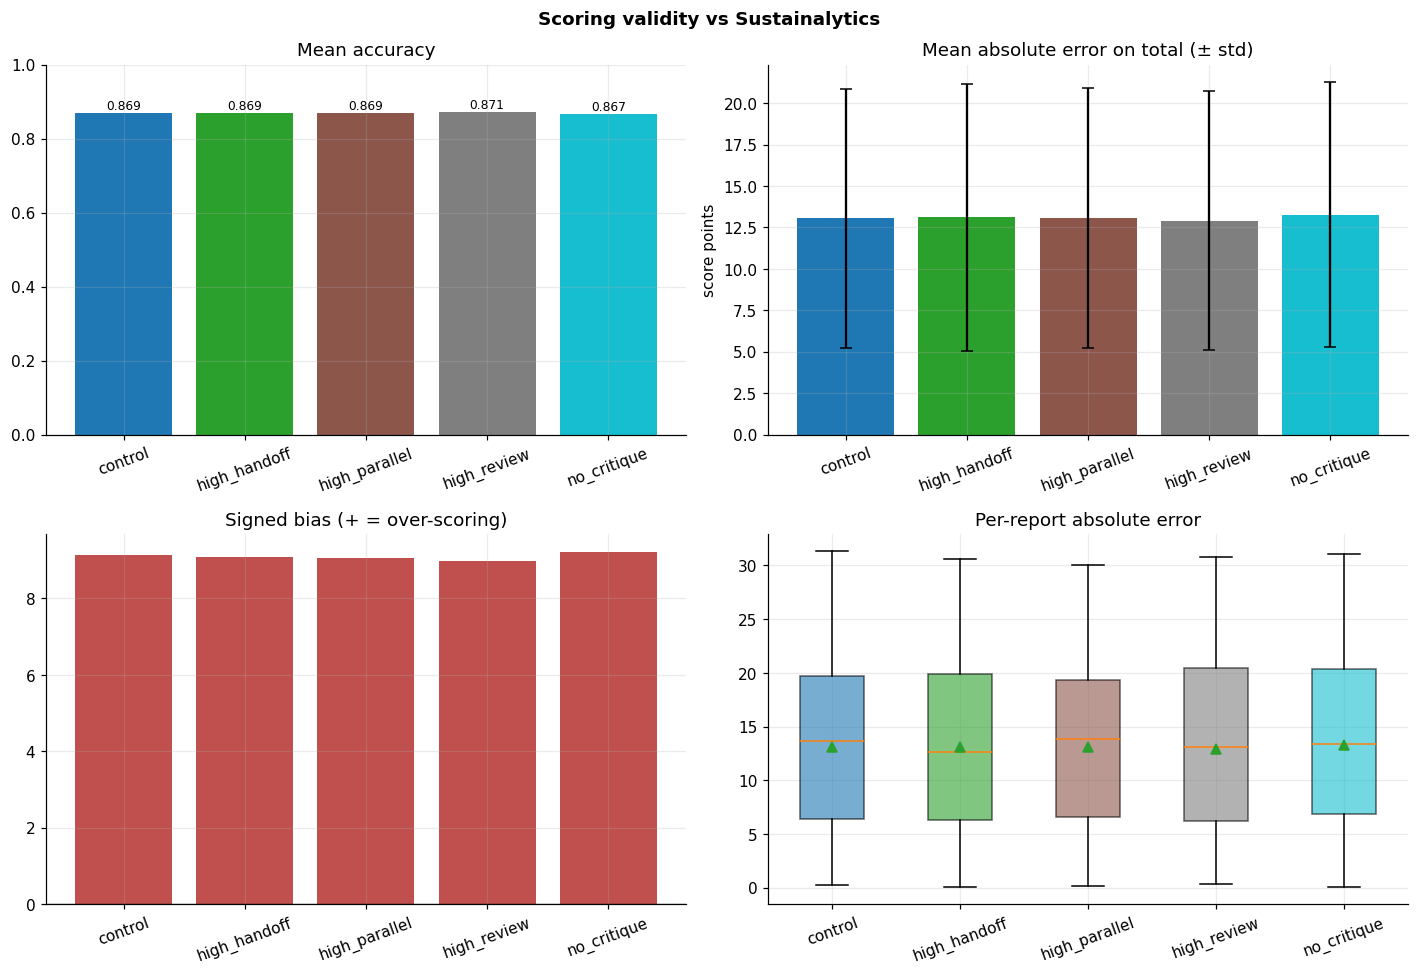

In [6]:
def plot_validity(df):
    g = GROUPS(df); colors = palette(len(g)); agg = df.groupby('group', observed=True)
    fig, ax = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle('Scoring validity vs Sustainalytics', fontweight='bold')

    acc = agg['accuracy'].mean().reindex(g)
    ax[0,0].bar(g, acc.values, color=colors); ax[0,0].set_ylim(0,1)
    ax[0,0].set_title('Mean accuracy')
    for i,v in enumerate(acc.values): ax[0,0].text(i, v+.01, f'{v:.3f}', ha='center', fontsize=8)

    mae = agg['absolute_error'].mean().reindex(g); sd = agg['absolute_error'].std().reindex(g)
    ax[0,1].bar(g, mae.values, yerr=sd.values, capsize=4, color=colors)
    ax[0,1].set_title('Mean absolute error on total (± std)'); ax[0,1].set_ylabel('score points')

    bias = agg.apply(lambda s: (s['total_score']-s['actual_total']).mean()).reindex(g)
    ax[1,0].bar(g, bias.values, color=['#c0504d' if v>0 else '#4f81bd' for v in bias.values])
    ax[1,0].axhline(0, color='k', lw=.8); ax[1,0].set_title('Signed bias (+ = over-scoring)')

    data = [df.loc[df['group']==x, 'absolute_error'].dropna() for x in g]
    bp = ax[1,1].boxplot(data, labels=g, patch_artist=True, showmeans=True)
    for p,c in zip(bp['boxes'], colors): p.set_facecolor(c); p.set_alpha(.6)
    ax[1,1].set_title('Per-report absolute error')

    for a in ax.flat: a.tick_params(axis='x', rotation=20)
    finish(fig, '01_validity.png')

plot_validity(reports_df)

## 5 · Predicted vs actual (calibration)

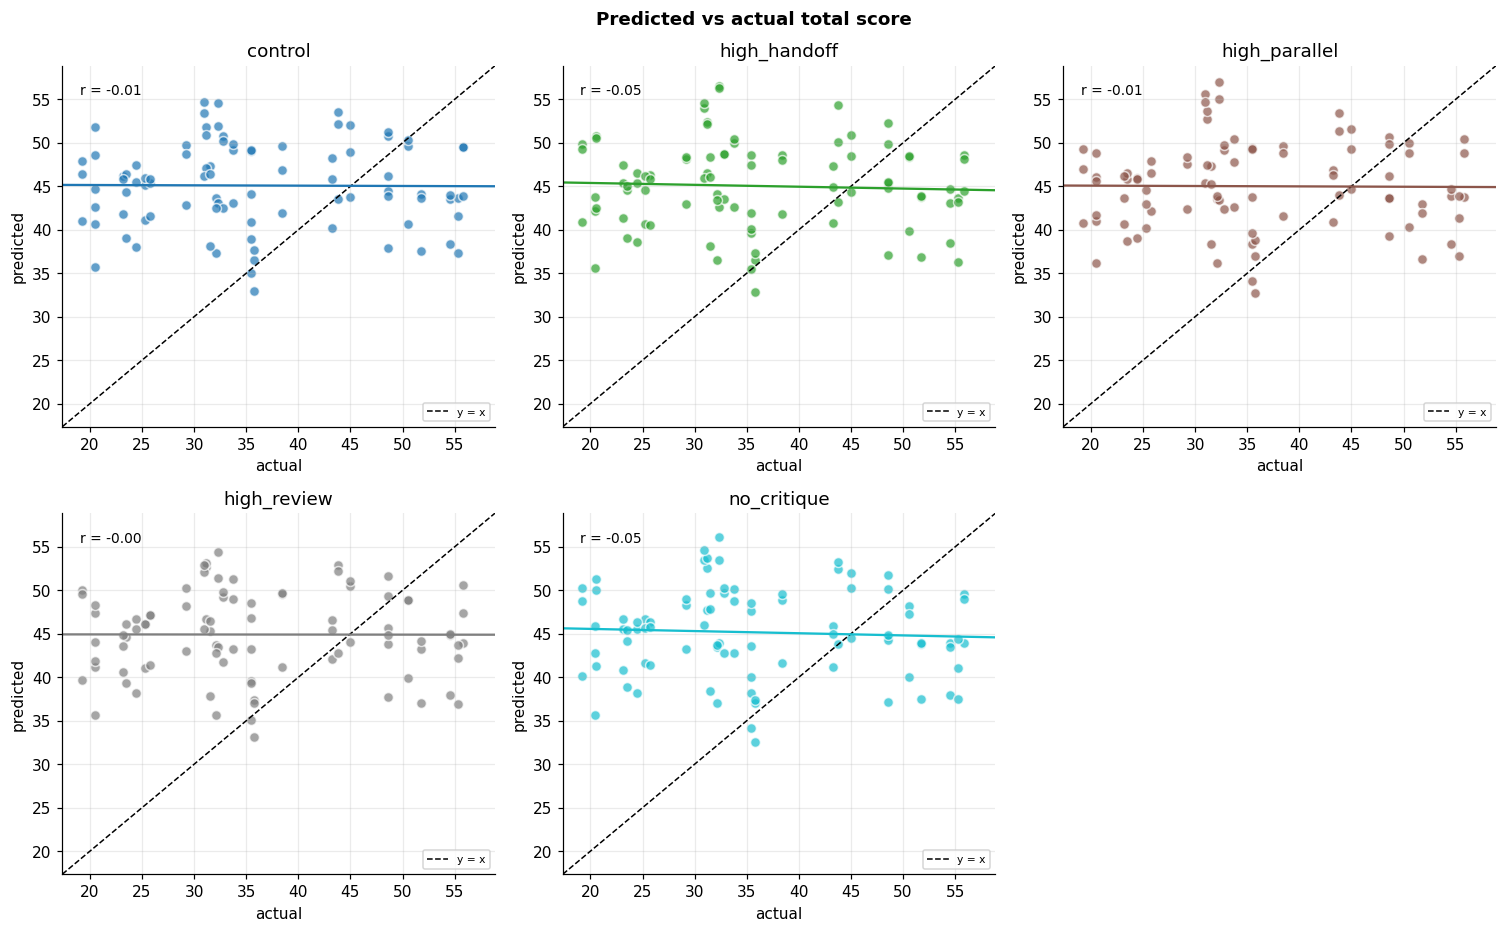

In [7]:
def plot_pred_actual(df):
    g = GROUPS(df); n=len(g); cols=min(3,n); rows=int(np.ceil(n/cols)); colors=palette(n)
    fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.3*rows), squeeze=False)
    fig.suptitle('Predicted vs actual total score', fontweight='bold')
    lo = np.nanmin([df['total_score'].min(), df['actual_total'].min()])
    hi = np.nanmax([df['total_score'].max(), df['actual_total'].max()])
    pad=.05*(hi-lo+1e-9); lim=(lo-pad, hi+pad)
    for i,x in enumerate(g):
        a = axes[i//cols][i%cols]; sub = df[df['group']==x]
        a.scatter(sub['actual_total'], sub['total_score'], color=colors[i], alpha=.7, s=42, edgecolor='white')
        a.plot(lim, lim, 'k--', lw=1, label='y = x')
        m = sub[['actual_total','total_score']].dropna()
        if len(m) >= 2:
            b1,b0 = np.polyfit(m['actual_total'], m['total_score'], 1); xs=np.array(lim)
            a.plot(xs, b1*xs+b0, color=colors[i], lw=1.5)
            a.text(.04,.92, f"r = {np.corrcoef(m['actual_total'], m['total_score'])[0,1]:.2f}",
                   transform=a.transAxes, fontsize=9)
        a.set_xlim(lim); a.set_ylim(lim); a.set_title(str(x)); a.set_xlabel('actual'); a.set_ylabel('predicted')
        a.legend(fontsize=7, loc='lower right')
    for j in range(n, rows*cols): axes[j//cols][j%cols].axis('off')
    finish(fig, '02_pred_actual.png')

plot_pred_actual(reports_df)

## 6 · Error direction & relative error

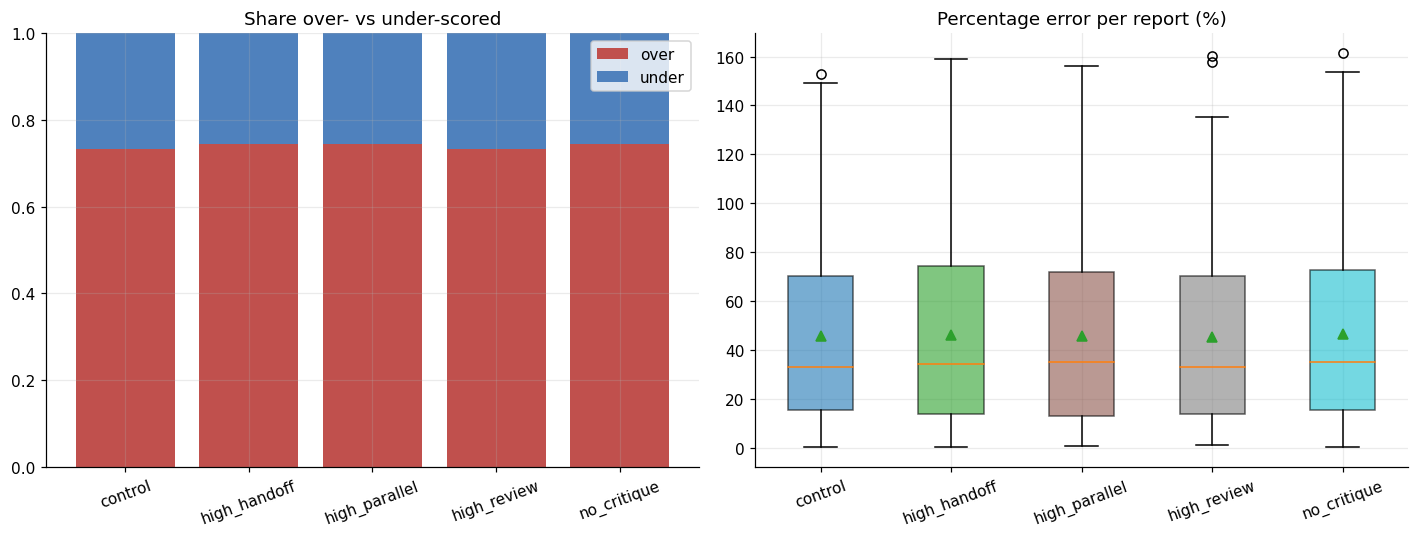

In [8]:
def plot_direction(df):
    g = GROUPS(df); colors=palette(len(g))
    fig,(ax1,ax2)=plt.subplots(1,2, figsize=(13,5))
    over =[(df[df['group']==x]['direction']=='over').mean() for x in g]
    under=[(df[df['group']==x]['direction']=='under').mean() for x in g]
    ax1.bar(g, over, label='over', color='#c0504d')
    ax1.bar(g, under, bottom=over, label='under', color='#4f81bd')
    ax1.set_ylim(0,1); ax1.set_title('Share over- vs under-scored'); ax1.legend(); ax1.tick_params(axis='x', rotation=20)
    data=[df.loc[df['group']==x,'percentage_error'].dropna() for x in g]
    bp=ax2.boxplot(data, labels=g, patch_artist=True, showmeans=True)
    for p,c in zip(bp['boxes'], colors): p.set_facecolor(c); p.set_alpha(.6)
    ax2.set_title('Percentage error per report (%)'); ax2.tick_params(axis='x', rotation=20)
    finish(fig, '03_direction.png')

plot_direction(reports_df)

## 7 · Trustworthiness & reliability

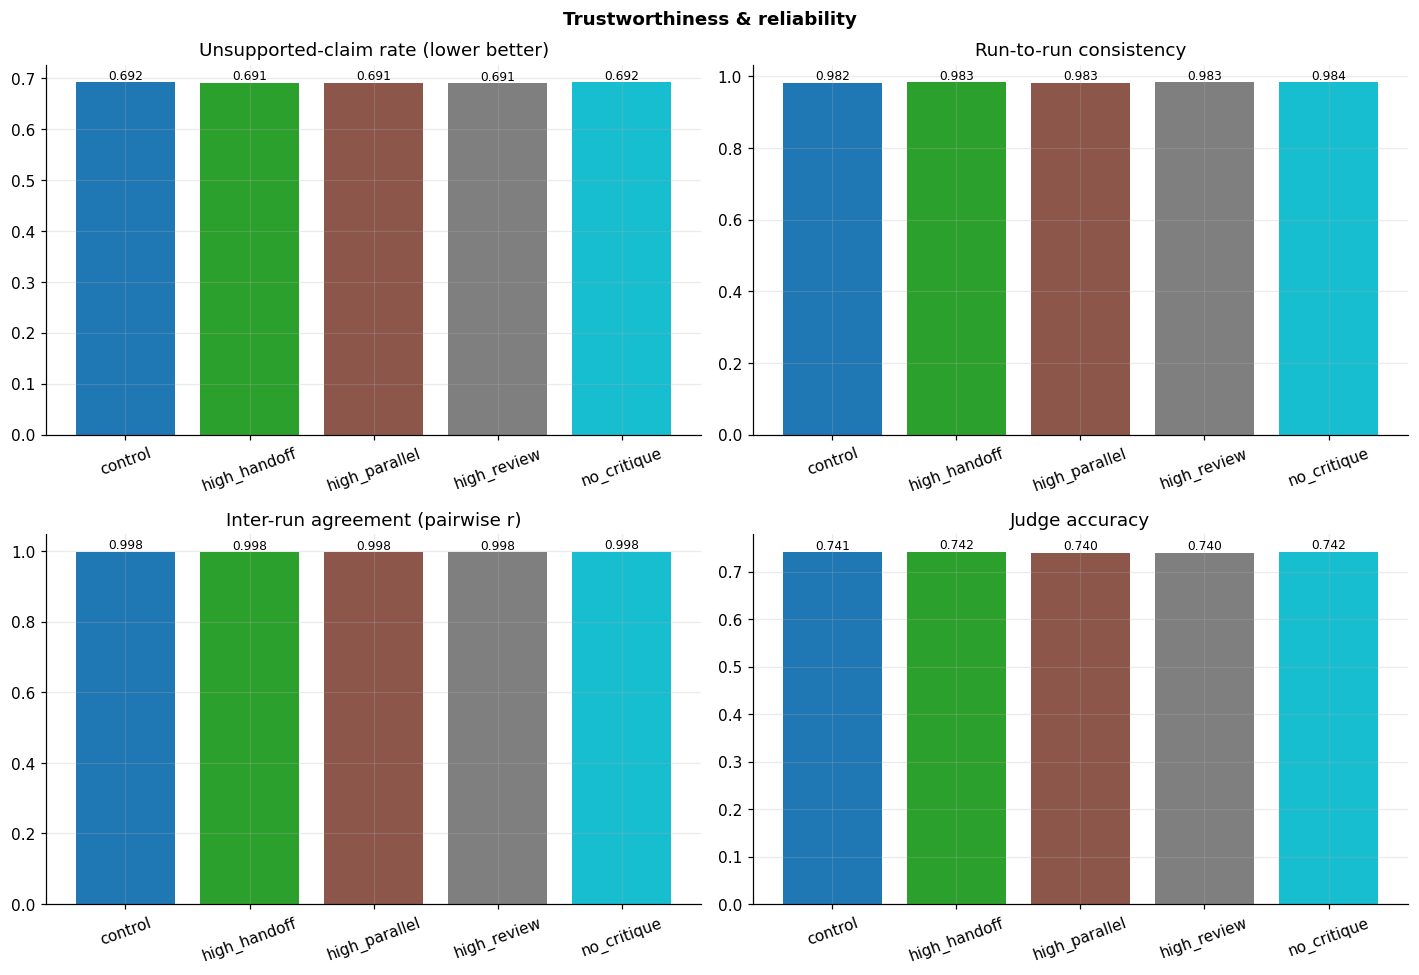

In [9]:
def plot_trust(df):
    g = GROUPS(df); colors=palette(len(g)); agg=df.groupby('group', observed=True)
    panels=[('hallucination_unsupported','Unsupported-claim rate (lower better)'),
            ('consistency_quantitative','Run-to-run consistency'),
            ('agreement_pairwise_pearson','Inter-run agreement (pairwise r)'),
            ('judge_accuracy','Judge accuracy')]
    fig,ax=plt.subplots(2,2, figsize=(13,9)); fig.suptitle('Trustworthiness & reliability', fontweight='bold')
    for k,(metric,title) in enumerate(panels):
        a=ax[k//2][k%2]
        if metric not in df.columns: a.axis('off'); a.set_title(f'{title}\n(n/a)'); continue
        v=agg[metric].mean().reindex(g); a.bar(g, v.values, color=colors); a.set_title(title)
        for i,val in enumerate(v.values):
            if np.isfinite(val): a.text(i, val, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        a.tick_params(axis='x', rotation=20)
    finish(fig, '04_trust.png')

plot_trust(reports_df)

## 8 · Cost & efficiency

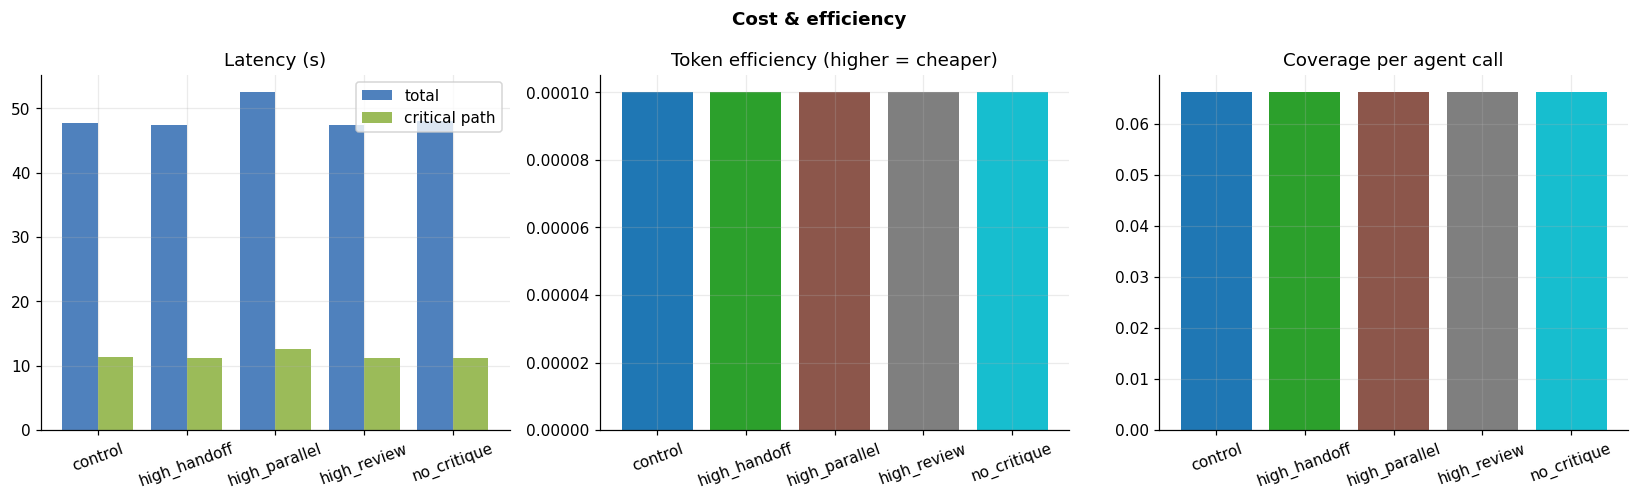

In [10]:
def plot_cost(df):
    g=GROUPS(df); colors=palette(len(g)); agg=df.groupby('group', observed=True); x=np.arange(len(g))
    fig,ax=plt.subplots(1,3, figsize=(15,4.6)); fig.suptitle('Cost & efficiency', fontweight='bold')
    lat=agg['latency_total'].mean().reindex(g); crit=agg['latency_critical_path'].mean().reindex(g)
    ax[0].bar(x-.2, lat.values, .4, label='total', color='#4f81bd')
    ax[0].bar(x+.2, crit.values, .4, label='critical path', color='#9bbb59')
    ax[0].set_xticks(x); ax[0].set_xticklabels(g, rotation=20); ax[0].set_title('Latency (s)'); ax[0].legend()
    ax[1].bar(g, agg['token_efficiency'].mean().reindex(g).values, color=colors)
    ax[1].set_title('Token efficiency (higher = cheaper)'); ax[1].tick_params(axis='x', rotation=20)
    ax[2].bar(g, agg['coverage_per_call'].mean().reindex(g).values, color=colors)
    ax[2].set_title('Coverage per agent call'); ax[2].tick_params(axis='x', rotation=20)
    finish(fig, '05_cost.png')

plot_cost(reports_df)

## 9 · Rubric coverage

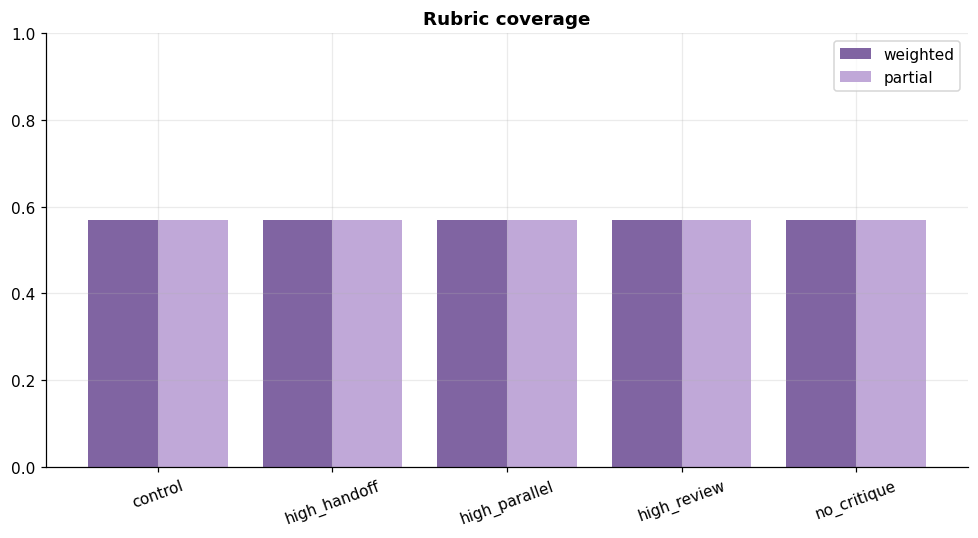

In [11]:
def plot_coverage(df):
    g=GROUPS(df); agg=df.groupby('group', observed=True); x=np.arange(len(g))
    cw=agg['coverage_weighted'].mean().reindex(g); cp=agg['coverage_partial'].mean().reindex(g)
    fig,ax=plt.subplots(figsize=(9,5))
    ax.bar(x-.2, cw.values, .4, label='weighted', color='#8064a2')
    ax.bar(x+.2, cp.values, .4, label='partial', color='#c0a8d8')
    ax.set_xticks(x); ax.set_xticklabels(g, rotation=20); ax.set_ylim(0,1)
    ax.set_title('Rubric coverage', fontweight='bold'); ax.legend()
    finish(fig, '06_coverage.png')

plot_coverage(reports_df)

## 10 · Quality vs cost trade-off

The core business chart: accuracy against latency, bubble size = unsupported-claim rate
(smaller = safer). Cheap, accurate, small bubbles sit in the top-left — the sweet spot.

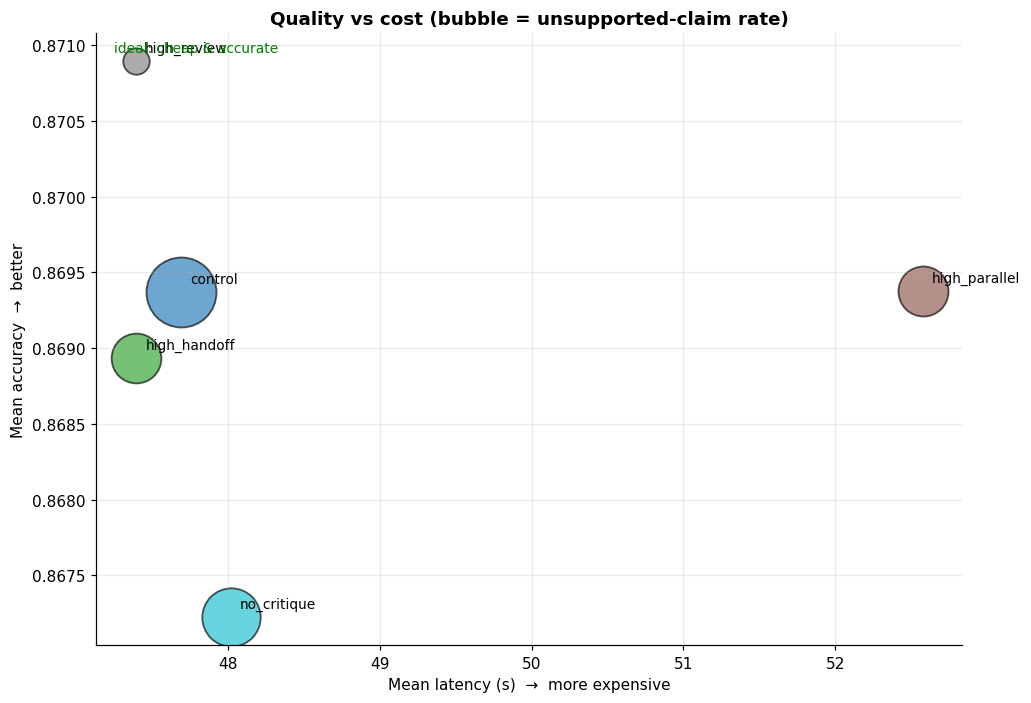

In [12]:
def plot_tradeoff(df):
    g=GROUPS(df); colors=palette(len(g)); agg=df.groupby('group', observed=True)
    acc=agg['accuracy'].mean().reindex(g); lat=agg['latency_total'].mean().reindex(g)
    hall=agg['hallucination_unsupported'].mean().reindex(g)
    sizes=300+1800*minmax(hall, True)
    fig,ax=plt.subplots(figsize=(9.5,6.5))
    for i,x in enumerate(g):
        ax.scatter(lat.iloc[i], acc.iloc[i], s=sizes.iloc[i], color=colors[i], alpha=.65,
                   edgecolor='black', linewidth=1.2)
        ax.annotate(str(x), (lat.iloc[i], acc.iloc[i]), xytext=(6,6), textcoords='offset points', fontsize=9)
    ax.set_xlabel('Mean latency (s)  →  more expensive')
    ax.set_ylabel('Mean accuracy  →  better')
    ax.set_title('Quality vs cost (bubble = unsupported-claim rate)', fontweight='bold')
    ax.annotate('ideal: cheap & accurate', xy=(.02,.97), xycoords='axes fraction', color='green', fontsize=9)
    finish(fig, '07_tradeoff.png')

plot_tradeoff(reports_df)

## 11 · Multi-metric profile (radar)

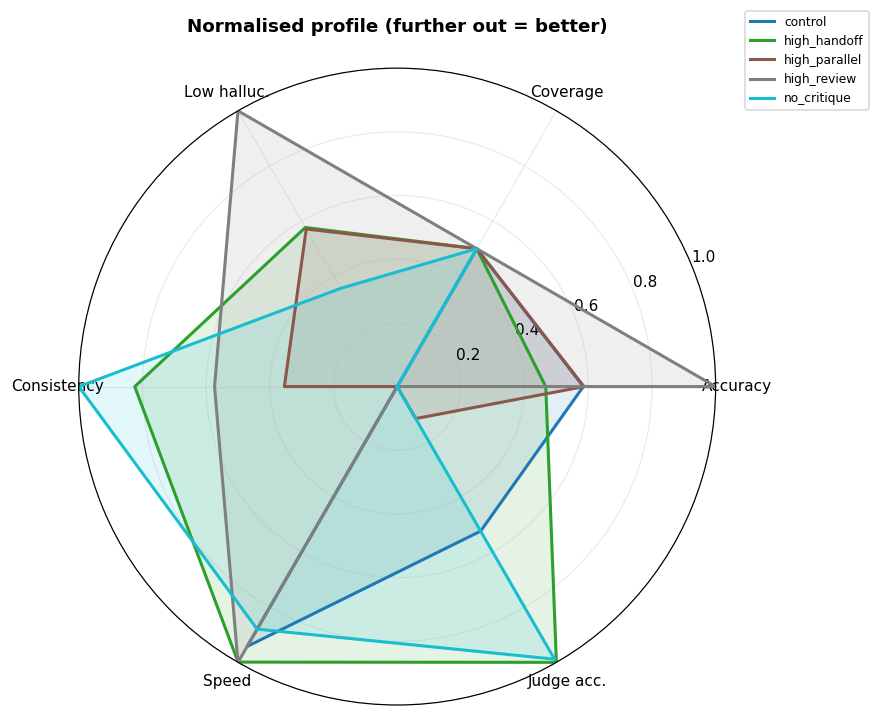

In [13]:
def plot_radar(df):
    g=GROUPS(df); colors=palette(len(g)); agg=df.groupby('group', observed=True).mean(numeric_only=True)
    spec=[('accuracy',True,'Accuracy'),('coverage_weighted',True,'Coverage'),
          ('hallucination_unsupported',False,'Low halluc.'),('consistency_quantitative',True,'Consistency'),
          ('latency_total',False,'Speed'),('judge_accuracy',True,'Judge acc.')]
    spec=[s for s in spec if s[0] in agg.columns]; labels=[s[2] for s in spec]
    norm=pd.DataFrame({s[2]: minmax(agg[s[0]], s[1]) for s in spec}, index=agg.index).reindex(g)
    ang=np.linspace(0,2*np.pi,len(labels),endpoint=False).tolist(); ang+=ang[:1]
    fig,ax=plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    for i,x in enumerate(g):
        vals=norm.loc[x].tolist()+[norm.loc[x].tolist()[0]]
        ax.plot(ang, vals, color=colors[i], lw=2, label=str(x)); ax.fill(ang, vals, color=colors[i], alpha=.12)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels); ax.set_ylim(0,1)
    ax.set_title('Normalised profile (further out = better)', fontweight='bold', pad=24)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25,1.1), fontsize=8)
    finish(fig, '08_radar.png')

plot_radar(reports_df)

## 12 · Domain-level behaviour

C:\Users\danie\AppData\Local\Temp\ipykernel_20376\3748597911.py:15: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=ax, fraction=.046, pad=.04)


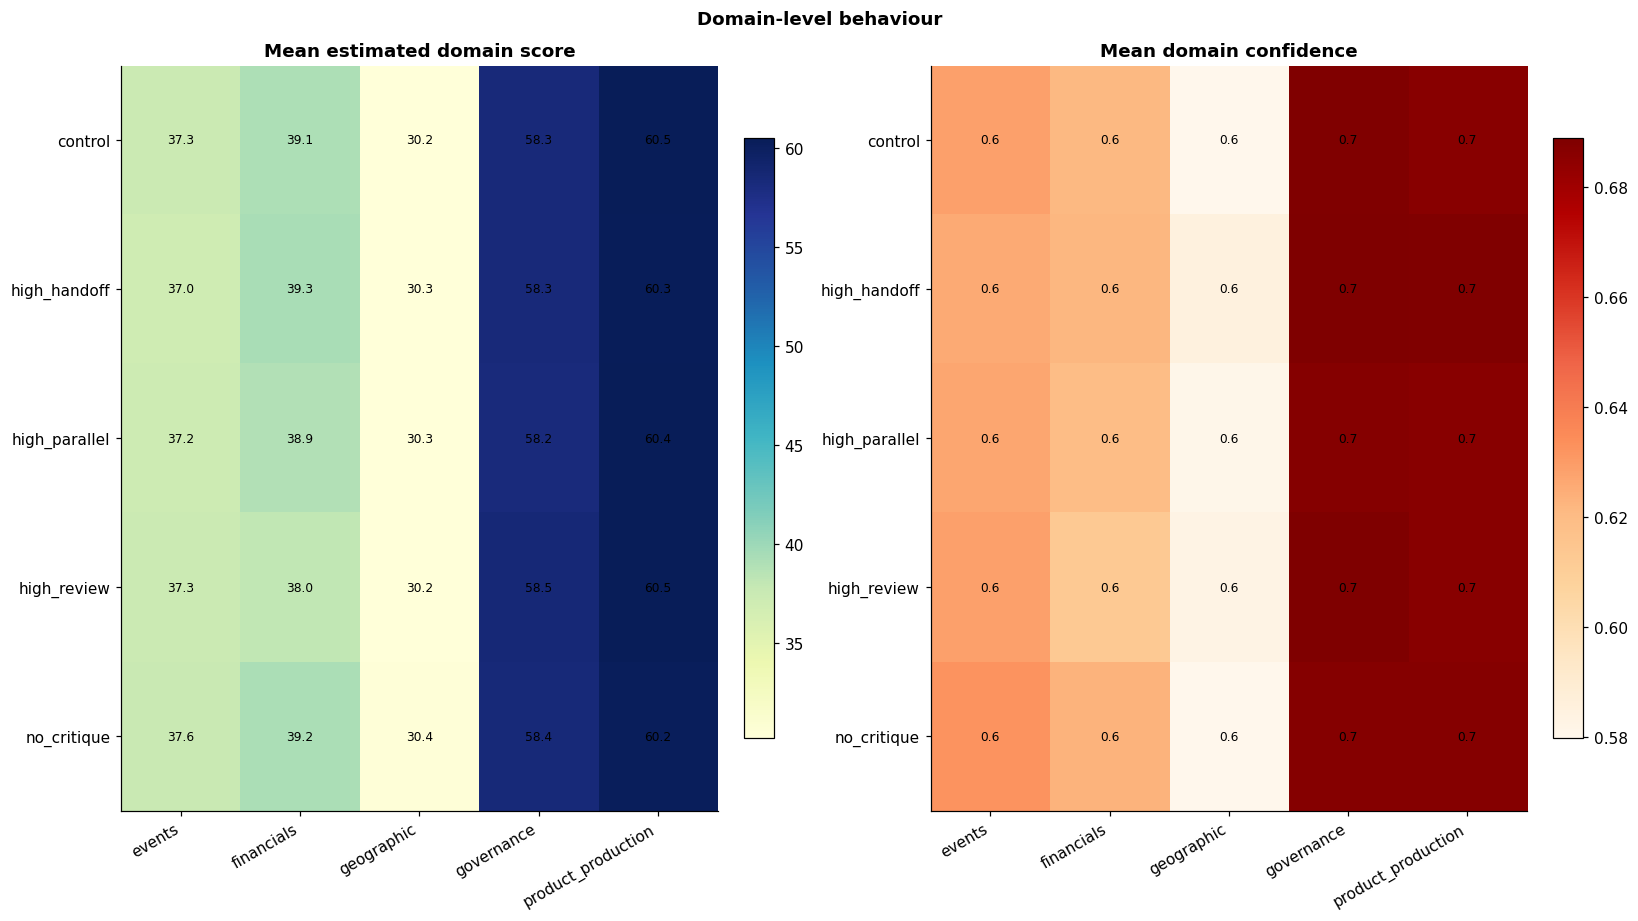

In [14]:
def plot_domains(df):
    if df.empty: print('no domain data'); return
    sp=df.pivot_table(index='group', columns='domain', values='estimated_score', aggfunc='mean', observed=True)
    cp=df.pivot_table(index='group', columns='domain', values='confidence', aggfunc='mean', observed=True)
    fig,axes=plt.subplots(1,2, figsize=(15, .9*len(sp)+4))
    for ax,piv,title,cmap in [(axes[0],sp,'Mean estimated domain score','YlGnBu'),
                              (axes[1],cp,'Mean domain confidence','OrRd')]:
        im=ax.imshow(piv.values, cmap=cmap, aspect='auto'); ax.grid(False)
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=30, ha='right')
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index); ax.set_title(title, fontweight='bold')
        for r in range(piv.shape[0]):
            for c in range(piv.shape[1]):
                v=piv.values[r,c]
                if np.isfinite(v): ax.text(c, r, f'{v:.1f}', ha='center', va='center', fontsize=8)
        fig.colorbar(im, ax=ax, fraction=.046, pad=.04)
    fig.suptitle('Domain-level behaviour', fontweight='bold')
    finish(fig, '09_domains.png')

plot_domains(domains_df)

## 13 · Confidence calibration

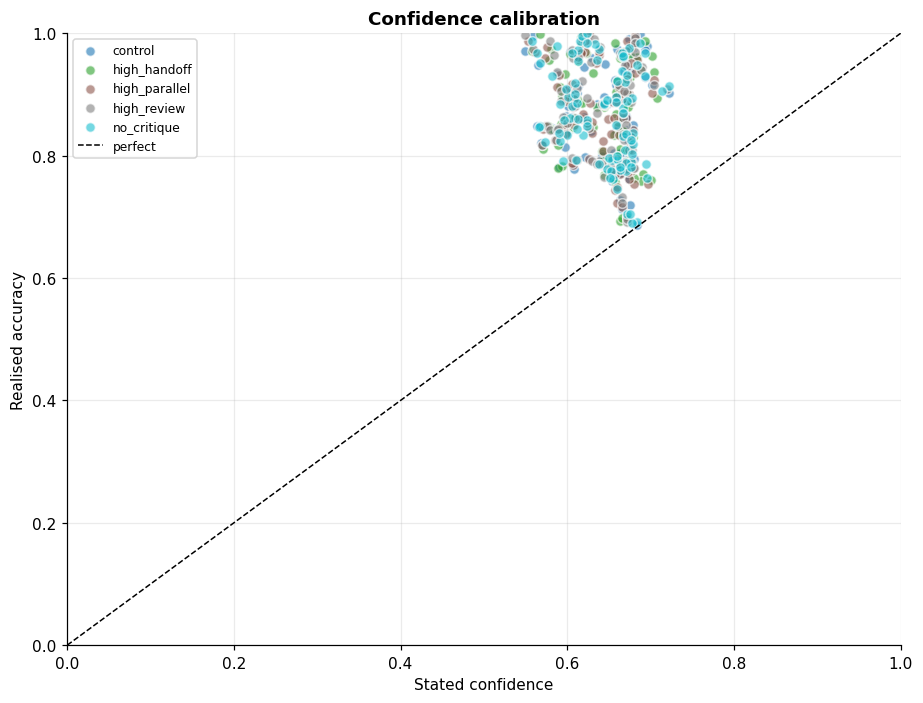

In [15]:
def plot_calibration(df):
    g=GROUPS(df); colors=palette(len(g))
    fig,ax=plt.subplots(figsize=(8.5,6.5))
    for i,x in enumerate(g):
        sub=df[df['group']==x]
        ax.scatter(sub['confidence'], sub['accuracy'], color=colors[i], alpha=.6, s=40,
                   edgecolor='white', label=str(x))
    ax.plot([0,1],[0,1],'k--', lw=1, label='perfect')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_xlabel('Stated confidence'); ax.set_ylabel('Realised accuracy')
    ax.set_title('Confidence calibration', fontweight='bold'); ax.legend(fontsize=8)
    finish(fig, '10_calibration.png')

plot_calibration(reports_df)

## 14 · Sub-pattern breakdown

Only meaningful when `FOCUS_PATTERN = 'all'`. Shows, for the headline metrics, how each
configuration affects the three internal sub-patterns — e.g. whether `high_handoff` really
lifts the `handoff_hierarchical` mode rather than the system as a whole.

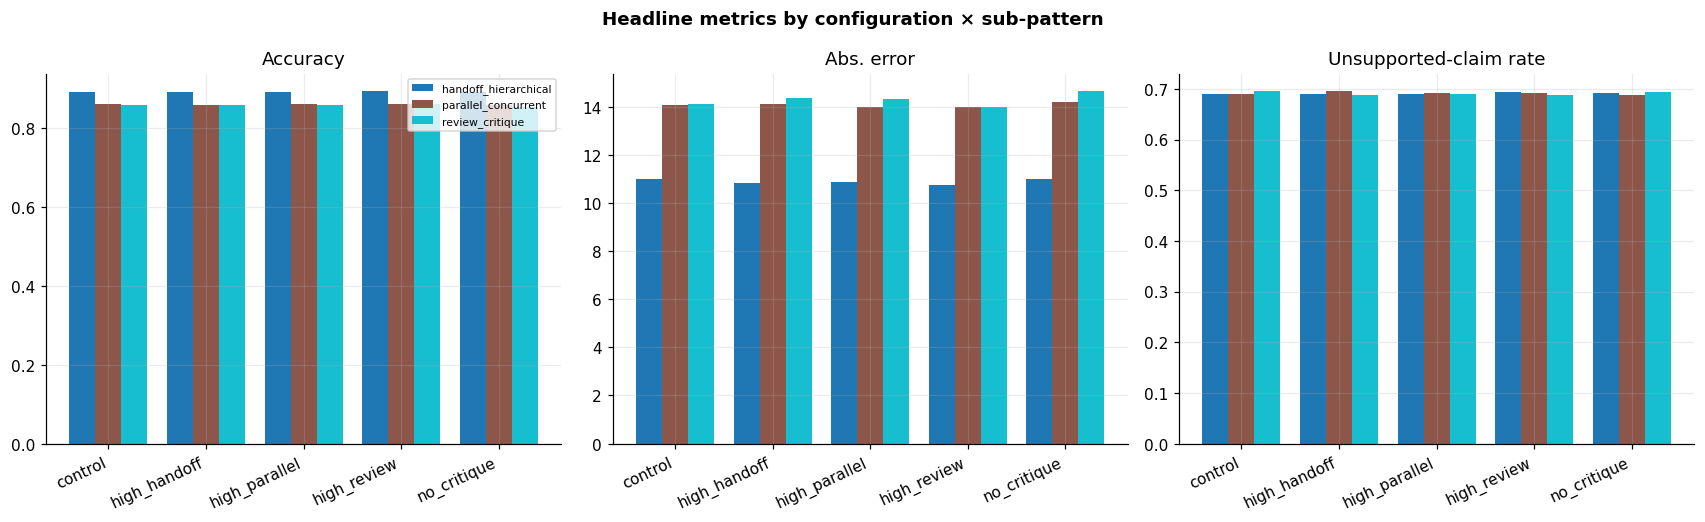

In [16]:
def plot_pattern_breakdown(raw):
    if FOCUS_PATTERN != 'all':
        print(f"FOCUS_PATTERN={FOCUS_PATTERN!r}; set to 'all' to see the sub-pattern breakdown.")
        return
    df = raw.copy()
    order=[l for l in FILES if l in set(df['experiment'])]
    df['experiment']=pd.Categorical(df['experiment'], categories=order, ordered=True)
    metrics=[('accuracy','Accuracy'),('absolute_error','Abs. error'),
             ('hallucination_unsupported','Unsupported-claim rate')]
    pats=sorted(df['pattern'].dropna().unique()); pcolors=palette(len(pats))
    fig,axes=plt.subplots(1,len(metrics), figsize=(5.2*len(metrics),4.8))
    for ax,(m,title) in zip(axes, metrics):
        piv=df.pivot_table(index='experiment', columns='pattern', values=m, aggfunc='mean', observed=True).reindex(order)
        x=np.arange(len(order)); w=.8/len(pats)
        for j,p in enumerate(pats):
            ax.bar(x+(j-(len(pats)-1)/2)*w, piv[p].values, w, label=p, color=pcolors[j])
        ax.set_xticks(x); ax.set_xticklabels(order, rotation=25, ha='right'); ax.set_title(title)
    axes[0].legend(fontsize=7)
    fig.suptitle('Headline metrics by configuration × sub-pattern', fontweight='bold')
    finish(fig, '11_pattern_breakdown.png')

plot_pattern_breakdown(reports_raw)

## 15 · Suitability scorecard

A 0–1 composite suitability index per configuration, built from five business pillars
(weights in the config cell), plus the underlying normalised sub-scores. This is the
direct answer to "which configuration, and is it good enough?".

C:\Users\danie\AppData\Local\Temp\ipykernel_20376\4281418824.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=ax2, fraction=.046, pad=.04)


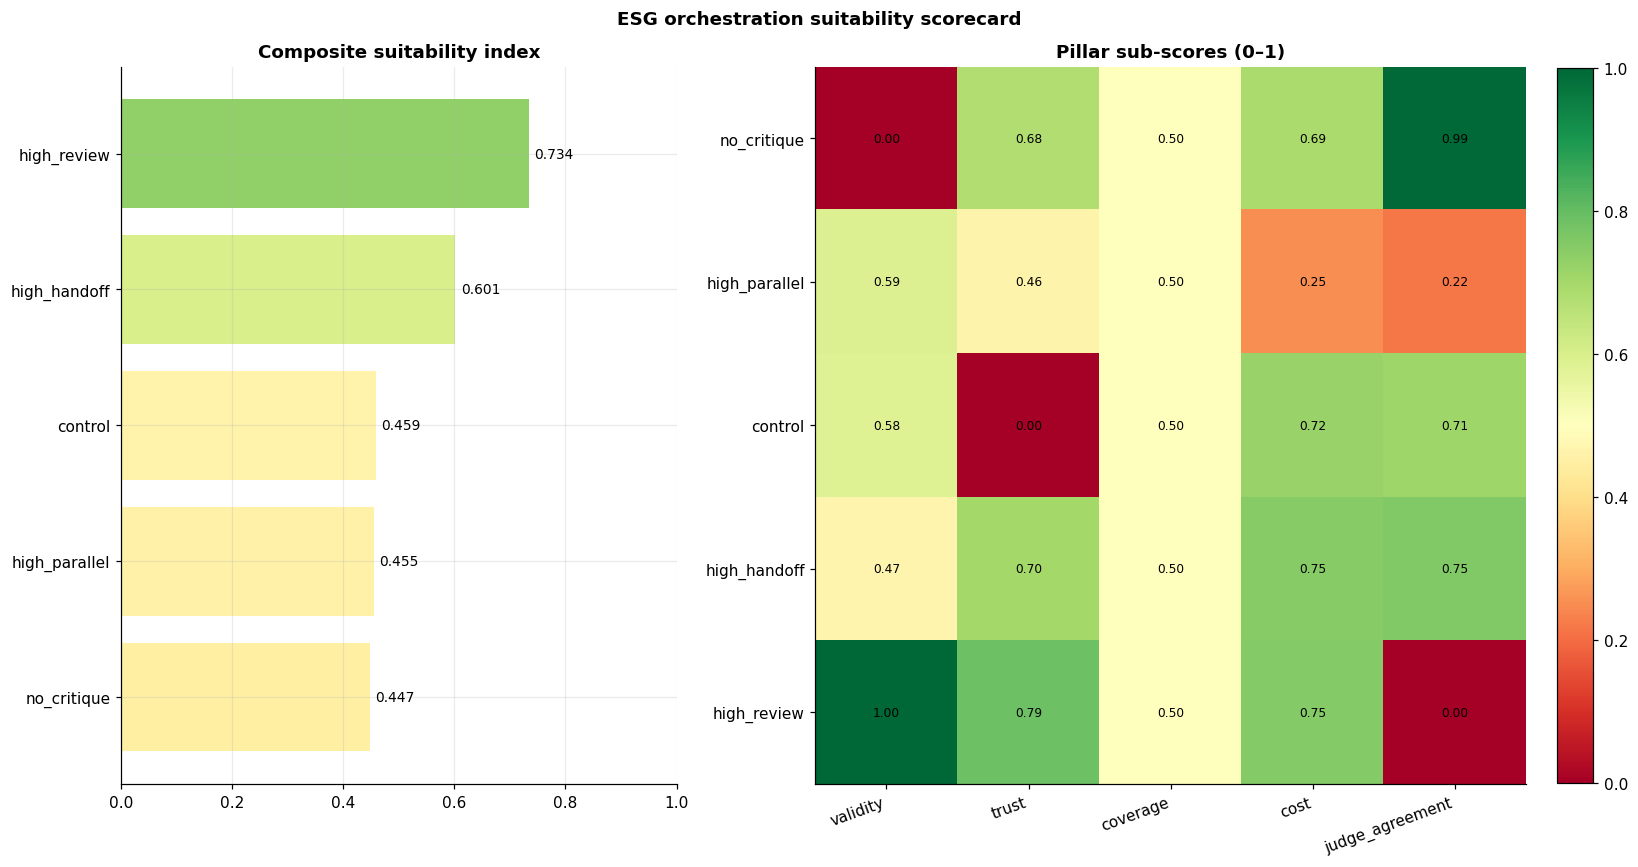

,validity,trust,coverage,cost,judge_agreement,SUITABILITY
group,,,,,,
high_review,1.000,0.787,0.5,0.750,0.000,0.734
high_handoff,0.467,0.701,0.5,0.750,0.754,0.601
control,0.585,0.000,0.5,0.721,0.710,0.459
high_parallel,0.587,0.463,0.5,0.250,0.216,0.455
no_critique,0.000,0.678,0.5,0.690,0.994,0.447


In [17]:
def composite_suitability(df):
    agg=df.groupby('group', observed=True).mean(numeric_only=True); idx=agg.index
    def col(name, hib):
        return minmax(agg[name], hib) if name in agg.columns else pd.Series(np.nan, index=idx)
    P=pd.DataFrame(index=idx)
    P['validity']=pd.concat([col('accuracy',True),
                             1-minmax(agg.get('absolute_error', pd.Series(np.nan,index=idx)), True)],axis=1).mean(axis=1)
    P['trust']=pd.concat([col('hallucination_unsupported',False), col('consistency_quantitative',True)],axis=1).mean(axis=1)
    P['coverage']=pd.concat([col('coverage_weighted',True), col('coverage_partial',True)],axis=1).mean(axis=1)
    P['cost']=pd.concat([col('latency_total',False), col('token_efficiency',True)],axis=1).mean(axis=1)
    P['judge_agreement']=pd.concat([col('judge_accuracy',True), col('agreement_pairwise_pearson',True)],axis=1).mean(axis=1)
    w=pd.Series(SUITABILITY_WEIGHTS); w=w/w.sum(); P=P[w.index]
    P['SUITABILITY']=(P*w).sum(axis=1)
    g=list(df['group'].cat.categories); P=P.reindex(g)

    comp=P['SUITABILITY']; order=comp.sort_values().index
    fig,(ax1,ax2)=plt.subplots(1,2, figsize=(15,.8*len(g)+4), gridspec_kw={'width_ratios':[1,1.4]})
    ax1.barh(range(len(order)), comp.reindex(order).values, color=plt.cm.RdYlGn(comp.reindex(order).values))
    ax1.set_yticks(range(len(order))); ax1.set_yticklabels(order); ax1.set_xlim(0,1)
    ax1.set_title('Composite suitability index', fontweight='bold')
    for i,v in enumerate(comp.reindex(order).values): ax1.text(v+.01, i, f'{v:.3f}', va='center', fontsize=9)
    sub=P.drop(columns='SUITABILITY').reindex(order)
    im=ax2.imshow(sub.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1); ax2.grid(False)
    ax2.set_xticks(range(sub.shape[1])); ax2.set_xticklabels(sub.columns, rotation=20, ha='right')
    ax2.set_yticks(range(sub.shape[0])); ax2.set_yticklabels(order); ax2.set_title('Pillar sub-scores (0–1)', fontweight='bold')
    for r in range(sub.shape[0]):
        for c in range(sub.shape[1]):
            v=sub.values[r,c]
            if np.isfinite(v): ax2.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax2, fraction=.046, pad=.04)
    fig.suptitle('ESG orchestration suitability scorecard', fontweight='bold')
    finish(fig, '12_scorecard.png')
    return P.sort_values('SUITABILITY', ascending=False)

scorecard = composite_suitability(reports_df)
scorecard.round(3)

## 16 · Business read-out

In [18]:
agg = reports_df.groupby('group', observed=True).mean(numeric_only=True)
cols=[c for c in ['accuracy','absolute_error','coverage_weighted','hallucination_unsupported',
                  'consistency_quantitative','latency_total','judge_accuracy'] if c in agg.columns]
print('Headline metrics (mean per configuration):')
print(agg[cols].round(3).to_string())

best=scorecard.index[0]
print(f"\nHighest composite suitability: {best!r} ({scorecard.loc[best,'SUITABILITY']:.3f}/1.00)")

acc=agg['accuracy'].max(); hall=agg['hallucination_unsupported'].min()
print(f"\nBest mean accuracy: {acc:.3f}   |   lowest unsupported-claim rate: {hall:.3f}")
if acc>=0.85 and hall<=0.40:
    v='PROMISING — strong accuracy with controllable hallucination.'
elif acc>=0.80:
    v='CONDITIONAL — usable accuracy, but hallucination needs mitigation before production.'
else:
    v='NOT YET — accuracy below a defensible threshold for ESG decisions.'
print('Verdict:', v)

Headline metrics (mean per configuration):
               accuracy  absolute_error  coverage_weighted  hallucination_unsupported  consistency_quantitative  latency_total  judge_accuracy
group                                                                                                                                         
control           0.869          13.063              0.568                      0.692                     0.982         47.691           0.741
high_handoff      0.869          13.106              0.568                      0.691                     0.983         47.398           0.742
high_parallel     0.869          13.062              0.568                      0.691                     0.983         52.577           0.740
high_review       0.871          12.910              0.568                      0.691                     0.983         47.394           0.740
no_critique       0.867          13.278              0.568                      0.692              

## 17 · Export tidy tables (optional)

In [ ]:
# reports_df.to_csv('reports_tidy.csv', index=False)
# summary_df.to_csv('summary_tidy.csv', index=False)
# scorecard.to_csv('suitability_scorecard.csv')
print('Uncomment to export. reports_df shape:', reports_df.shape)